# CODSOFT - Data Science Internship

## Task 3: Iris Flower Classification

### Objective

The objective of this project is to develop a machine learning model that classifies Iris flowers into different species based on their sepal and petal measurements.

### Dataset

The Iris dataset contains measurements of Iris flowers belonging to three species: Setosa, Versicolor, and Virginica.

### Machine Learning Approach

A classification model will be trained using the flower measurements and evaluated using accuracy, classification report, and confusion matrix.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
df = pd.read_csv("IRIS.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Distribution:")
print(df["species"].value_counts())

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


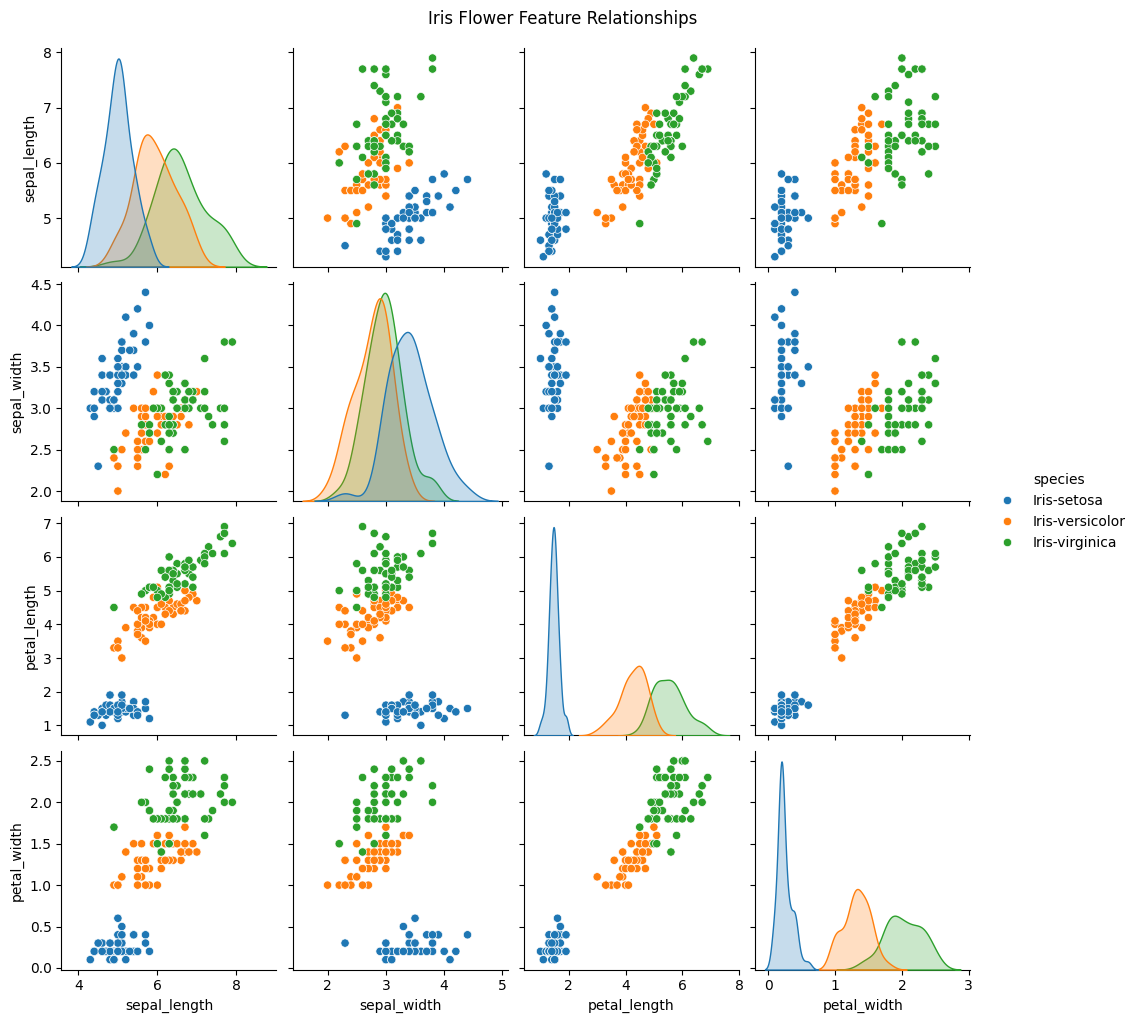

In [16]:
sns.pairplot(df, hue="species")

plt.suptitle(
    "Iris Flower Feature Relationships",
    y=1.02
)

plt.show()

In [17]:
X = df.drop("species", axis=1)
y = df["species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.unique())

Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [20]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 90.0 %


In [22]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



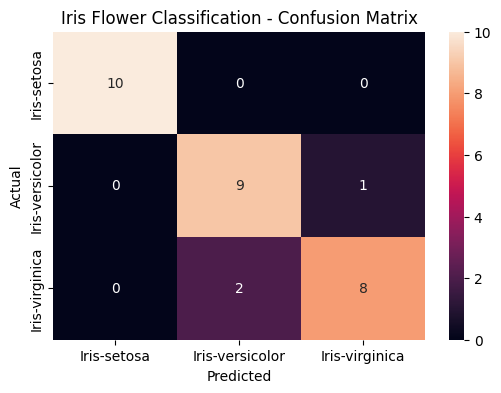

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iris Flower Classification - Confusion Matrix")

plt.show()

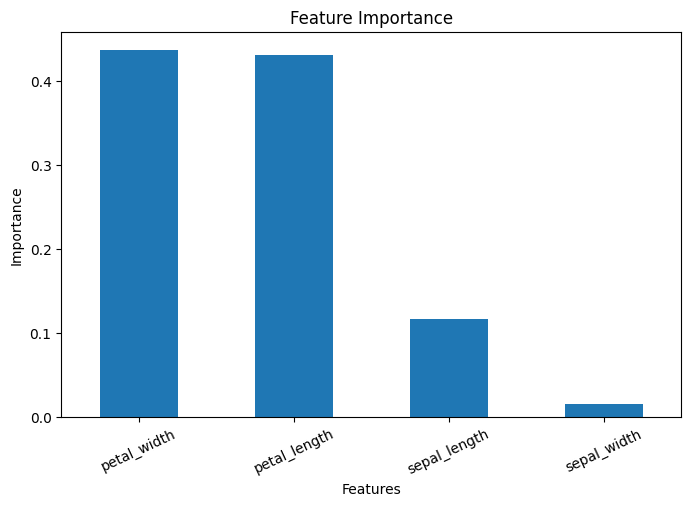

In [24]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=25)

plt.show()

In [25]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Conclusion

In this project, a Random Forest Classification model was developed to classify Iris flowers into Setosa, Versicolor, and Virginica species using their sepal and petal measurements.

The dataset was loaded from the provided IRIS.csv file and explored before training the model. The model was evaluated using accuracy, classification report, and confusion matrix. Feature importance was also analyzed to understand the contribution of different measurements.

The project demonstrates the complete machine learning workflow, including data loading, exploration, visualization, model training, prediction, and evaluation.
